CMAPSS DATASET ANALYSIS

📁 Please upload your CMAPSS dataset ZIP file
The ZIP should contain: train_FD001.txt, test_FD001.txt, RUL_FD001.txt
(Also works with FD002, FD003, FD004 if you have them)


Saving NASA CMAPSS Turbofan Engine RUL Dataset.zip to NASA CMAPSS Turbofan Engine RUL Dataset (11).zip

✅ Received: NASA CMAPSS Turbofan Engine RUL Dataset (11).zip

📋 Files in ZIP: ['RUL_FD001.txt', 'RUL_FD002.txt', 'RUL_FD003.txt', 'RUL_FD004.txt', 'readme.txt', 'test_FD001.txt', 'test_FD002.txt', 'test_FD003.txt', 'test_FD004.txt', 'train_FD001.txt', 'train_FD002.txt', 'train_FD003.txt', 'train_FD004.txt']

📊 Available datasets:
   FD003: ✅ Complete
   FD001: ✅ Complete
   FD002: ✅ Complete
   FD004: ✅ Complete

DATASET RECOMMENDATION

✅ RECOMMENDED: FD001
   - Single operating condition
   - Single fault mode
   - Simplest and most predictable
   - Best for first-time deployment

LOADING FD001 DATASET

✅ Training data: 20631 rows, 26 columns
   Units in training: 100
   Cycles range: 1 - 362

✅ Test data: 13096 rows, 26 columns
   Units in test: 100

✅ RUL data: 100 rows (one per test unit)

SENSOR ANALYSIS

📊 Sensors with degradation trends:
                  mean    variance     

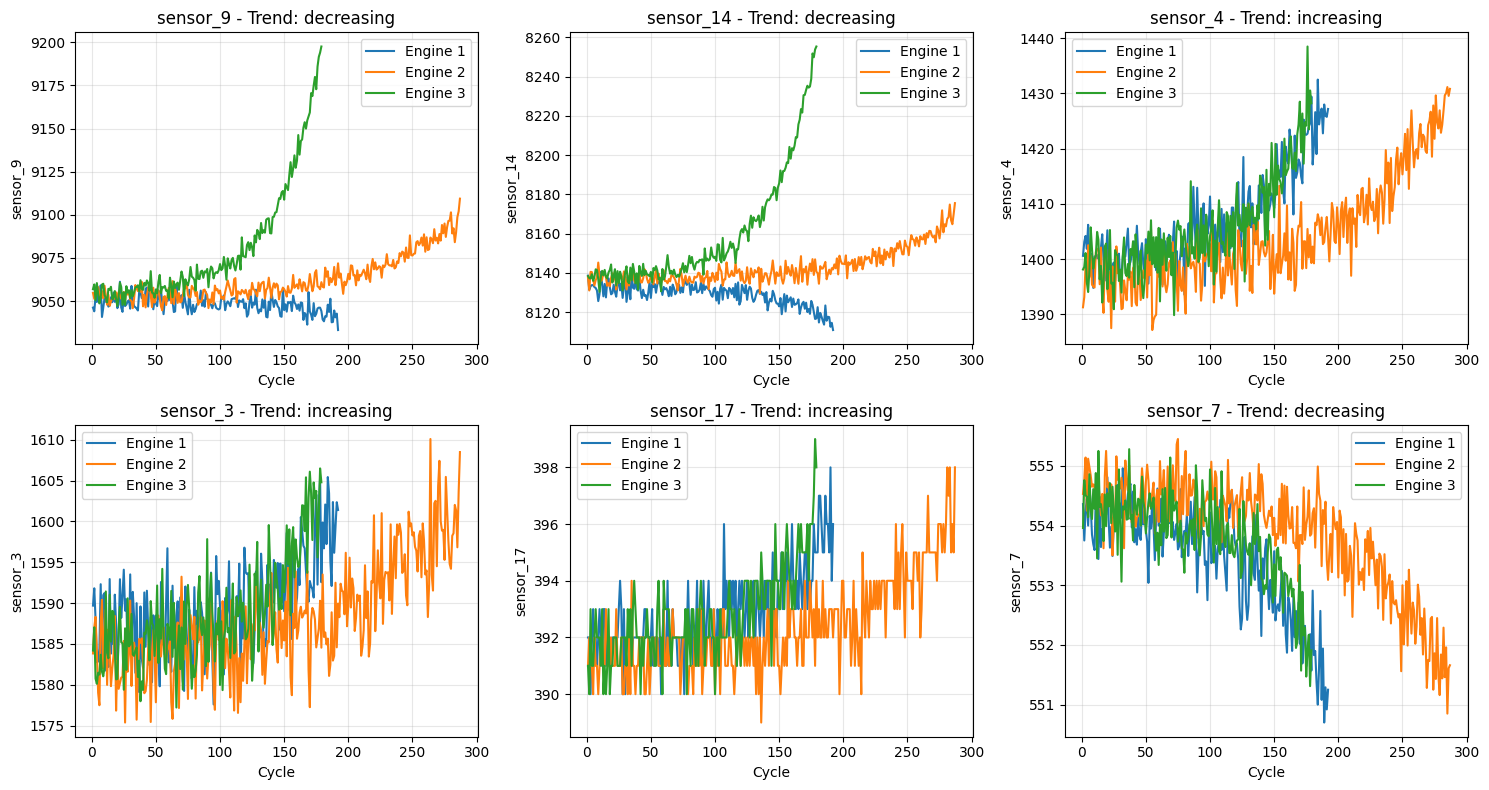


ANALYSIS COMPLETE

📌 Recommendation: Train on FD001
📌 Useful sensors: 14 show degradation trends
📌 Training size: 20631 rows - sufficient for Random Forest


In [11]:
# STEP 1: UPLOAD AND ANALYZE CMAPSS DATASET
import pandas as pd
import numpy as np
import zipfile
import io
from google.colab import files
import matplotlib.pyplot as plt

print("="*70)
print("CMAPSS DATASET ANALYSIS")
print("="*70)

# Upload ZIP file
print("\n📁 Please upload your CMAPSS dataset ZIP file")
print("The ZIP should contain: train_FD001.txt, test_FD001.txt, RUL_FD001.txt")
print("(Also works with FD002, FD003, FD004 if you have them)")

uploaded = files.upload()

# Find the ZIP file
zip_filename = None
for filename in uploaded.keys():
    if filename.endswith('.zip'):
        zip_filename = filename
        break

if not zip_filename:
    raise FileNotFoundError("❌ No ZIP file uploaded")

print(f"\n✅ Received: {zip_filename}")

# Extract and explore
zip_data = io.BytesIO(uploaded[zip_filename])
with zipfile.ZipFile(zip_data, 'r') as zip_ref:
    zip_ref.extractall('/tmp/cmapss_data/')
    files_list = zip_ref.namelist()
    print(f"\n📋 Files in ZIP: {files_list}")

# Find all available datasets
import os
data_dir = '/tmp/cmapss_data/'
available_sets = {}

for file in os.listdir(data_dir):
    if file.endswith('.txt'):
        # Detect which FD set
        if 'FD001' in file:
            set_name = 'FD001'
        elif 'FD002' in file:
            set_name = 'FD002'
        elif 'FD003' in file:
            set_name = 'FD003'
        elif 'FD004' in file:
            set_name = 'FD004'
        else:
            continue

        if set_name not in available_sets:
            available_sets[set_name] = {}

        if 'train' in file.lower():
            available_sets[set_name]['train'] = file
        elif 'test' in file.lower():
            available_sets[set_name]['test'] = file
        elif 'rul' in file.lower():
            available_sets[set_name]['rul'] = file

print(f"\n📊 Available datasets:")
for set_name, files_dict in available_sets.items():
    status = "✅ Complete" if len(files_dict) == 3 else "⚠️ Incomplete"
    print(f"   {set_name}: {status}")

# Choose the best dataset
print("\n" + "="*70)
print("DATASET RECOMMENDATION")
print("="*70)

if 'FD001' in available_sets and len(available_sets['FD001']) == 3:
    recommended = 'FD001'
    print("\n✅ RECOMMENDED: FD001")
    print("   - Single operating condition")
    print("   - Single fault mode")
    print("   - Simplest and most predictable")
    print("   - Best for first-time deployment")
elif 'FD003' in available_sets:
    recommended = 'FD003'
    print("\n✅ RECOMMENDED: FD003")
    print("   - Single operating condition")
    print("   - Two fault modes")
    print("   - Still manageable")
else:
    recommended = list(available_sets.keys())[0]
    print(f"\n⚠️ Using: {recommended}")

# Load the chosen dataset
print("\n" + "="*70)
print(f"LOADING {recommended} DATASET")
print("="*70)

COLUMN_NAMES = ['unit_nr', 'cycle'] + \
               [f'op_setting_{i}' for i in range(1, 4)] + \
               [f'sensor_{i}' for i in range(1, 22)]

train_file = available_sets[recommended]['train']
test_file = available_sets[recommended]['test']
rul_file = available_sets[recommended]['rul']

df_train = pd.read_csv(os.path.join(data_dir, train_file),
                       sep='\s+', header=None, names=COLUMN_NAMES)
df_test = pd.read_csv(os.path.join(data_dir, test_file),
                      sep='\s+', header=None, names=COLUMN_NAMES)
df_rul = pd.read_csv(os.path.join(data_dir, rul_file),
                     sep='\s+', header=None, names=['RUL'])

print(f"\n✅ Training data: {df_train.shape[0]} rows, {df_train.shape[1]} columns")
print(f"   Units in training: {df_train['unit_nr'].nunique()}")
print(f"   Cycles range: {df_train['cycle'].min()} - {df_train['cycle'].max()}")

print(f"\n✅ Test data: {df_test.shape[0]} rows, {df_test.shape[1]} columns")
print(f"   Units in test: {df_test['unit_nr'].nunique()}")

print(f"\n✅ RUL data: {df_rul.shape[0]} rows (one per test unit)")

# Analyze sensor behavior
print("\n" + "="*70)
print("SENSOR ANALYSIS")
print("="*70)

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
sensor_stats = df_train[sensor_cols].describe().T
sensor_stats['variance'] = df_train[sensor_cols].var()
sensor_stats['trend'] = 'unknown'

# Check which sensors show degradation trends
for sensor in sensor_cols:
    # Take one engine and check if sensor degrades over time
    sample_engine = df_train[df_train['unit_nr'] == 1]
    if len(sample_engine) > 10:
        correlation = sample_engine[sensor].corr(sample_engine['cycle'])
        if correlation > 0.3:
            sensor_stats.loc[sensor, 'trend'] = 'increasing'
        elif correlation < -0.3:
            sensor_stats.loc[sensor, 'trend'] = 'decreasing'
        else:
            sensor_stats.loc[sensor, 'trend'] = 'stable'

# Show most useful sensors
useful_sensors = sensor_stats[sensor_stats['trend'] != 'stable'].sort_values('variance', ascending=False)
print(f"\n📊 Sensors with degradation trends:")
print(useful_sensors[['mean', 'variance', 'trend']].head(10))

# Visualize key sensors
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
key_sensors = useful_sensors.head(6).index.tolist()

for idx, sensor in enumerate(key_sensors):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]

    # Plot sensor value over cycles for first 3 engines
    for engine in [1, 2, 3]:
        engine_data = df_train[df_train['unit_nr'] == engine]
        ax.plot(engine_data['cycle'], engine_data[sensor], label=f'Engine {engine}')

    ax.set_xlabel('Cycle')
    ax.set_ylabel(sensor)
    ax.set_title(f'{sensor} - Trend: {sensor_stats.loc[sensor, "trend"]}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)
print(f"\n📌 Recommendation: Train on {recommended}")
print(f"📌 Useful sensors: {len(useful_sensors)} show degradation trends")
print(f"📌 Training size: {len(df_train)} rows - sufficient for Random Forest")

TRAINING SIMPLE RANDOM FOREST MODEL ON FD001

📊 Using 14 features:
   - Current cycle
   - op_setting_1, op_setting_2, op_setting_3
   - 10 degrading sensors: ['sensor_9', 'sensor_14', 'sensor_4', 'sensor_3', 'sensor_17', 'sensor_7', 'sensor_12', 'sensor_2', 'sensor_11', 'sensor_20']

📝 Preparing training data...
   Training samples: 20,631
   Features shape: (20631, 14)
   RUL range (capped): 0 - 125 cycles

   Train engines: 80 (16,340 samples)
   Validation engines: 20 (4,291 samples)

🔄 Scaling features...

🤖 Training Random Forest (this takes 2-3 minutes)...

📊 Validation Performance:
   MAE:  11.73 cycles
   RMSE: 16.83 cycles
   R²:   0.8356

🏆 Top 10 Most Important Features:
   sensor_11            0.4460 ██████████████████████
   cycle                0.3462 █████████████████
   sensor_9             0.0581 ██
   sensor_12            0.0369 █
   sensor_4             0.0325 █
   sensor_7             0.0209 █
   sensor_14            0.0174 
   sensor_2             0.0113 
   senso

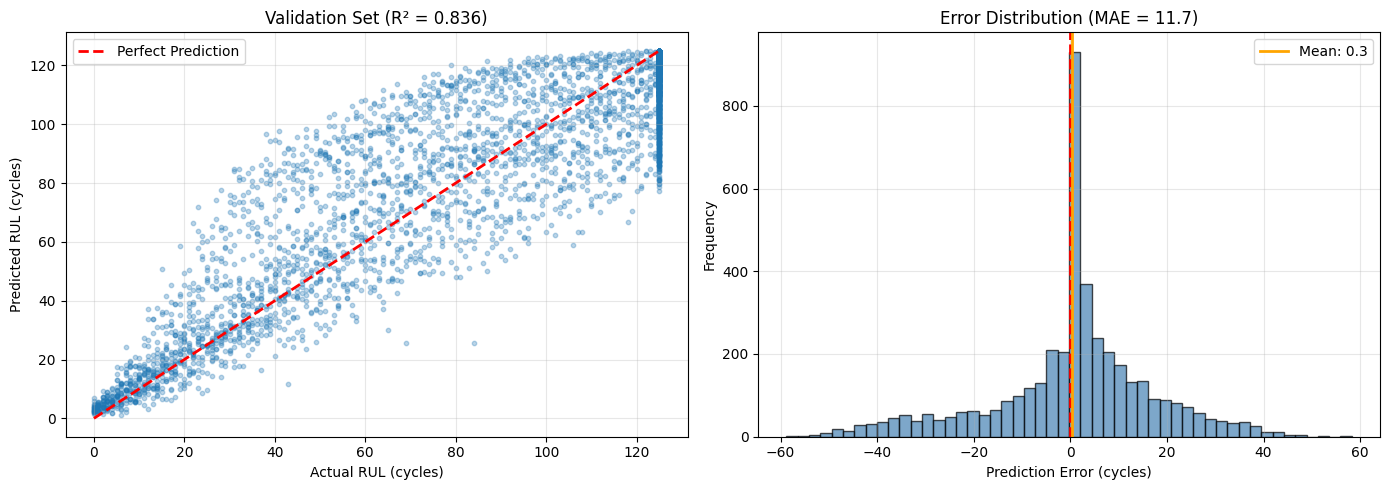


💾 Saving model artifacts...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ TRAINING COMPLETE!

📦 artifacts.zip downloaded to your computer

📊 Model Performance Summary:
   ✅ Validation MAE:  11.73 cycles
   ✅ Validation RMSE: 16.83 cycles
   ✅ Validation R²:   0.8356

🎉 EXCELLENT! Model is ready for deployment.

📁 artifacts.zip contains:
   - rul_model.joblib (trained Random Forest)
   - feature_scaler.joblib (for scaling inputs)
   - model_config.json (feature names and config)
   - sample_input.json (example for testing)


In [13]:
# STEP 2: TRAIN SIMPLE RELIABLE MODEL ON FD001
print("="*70)
print("TRAINING SIMPLE RANDOM FOREST MODEL ON FD001")
print("="*70)

# Use sensors that show degradation trends (from analysis above)
useful_sensors = [
    'sensor_9', 'sensor_14', 'sensor_4', 'sensor_3',
    'sensor_17', 'sensor_7', 'sensor_12', 'sensor_2',
    'sensor_11', 'sensor_20'
]

feature_cols = ['cycle'] + [f'op_setting_{i}' for i in range(1, 4)] + useful_sensors

print(f"\n📊 Using {len(feature_cols)} features:")
print(f"   - Current cycle")
print(f"   - op_setting_1, op_setting_2, op_setting_3")
print(f"   - 10 degrading sensors: {useful_sensors}")

# Prepare training data
print("\n📝 Preparing training data...")

# Calculate RUL for training data
max_cycles = df_train.groupby('unit_nr')['cycle'].max().reset_index()
max_cycles.columns = ['unit_nr', 'max_cycle']
df_train_rul = df_train.merge(max_cycles, on='unit_nr')
df_train_rul['RUL'] = df_train_rul['max_cycle'] - df_train_rul['cycle']
df_train_rul = df_train_rul.drop('max_cycle', axis=1)

# Cap RUL at 125 cycles (focus on critical region where predictions matter most)
MAX_RUL = 125
df_train_rul['RUL_capped'] = df_train_rul['RUL'].clip(upper=MAX_RUL)

X_train = df_train_rul[feature_cols]
y_train = df_train_rul['RUL_capped']

print(f"   Training samples: {len(X_train):,}")
print(f"   Features shape: {X_train.shape}")
print(f"   RUL range (capped): {y_train.min()} - {y_train.max()} cycles")

# Split by engine to avoid data leakage
unique_engines = df_train_rul['unit_nr'].unique()
np.random.seed(42)
train_engines = np.random.choice(unique_engines, size=int(0.8 * len(unique_engines)), replace=False)
val_engines = [e for e in unique_engines if e not in train_engines]

train_mask = df_train_rul['unit_nr'].isin(train_engines)
val_mask = df_train_rul['unit_nr'].isin(val_engines)

X_train_split = X_train[train_mask]
y_train_split = y_train[train_mask]
X_val = X_train[val_mask]
y_val = y_train[val_mask]

print(f"\n   Train engines: {len(train_engines)} ({len(X_train_split):,} samples)")
print(f"   Validation engines: {len(val_engines)} ({len(X_val):,} samples)")

# Scale features
print("\n🔄 Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val)

# Train model
print("\n🤖 Training Random Forest (this takes 2-3 minutes)...")
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

model.fit(X_train_scaled, y_train_split)

# Evaluate on validation set
print("\n📊 Validation Performance:")
y_val_pred = model.predict(X_val_scaled)
y_val_pred = np.clip(y_val_pred, 0, MAX_RUL)

val_mae = mean_absolute_error(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2 = r2_score(y_val, y_val_pred)

print(f"   MAE:  {val_mae:.2f} cycles")
print(f"   RMSE: {val_rmse:.2f} cycles")
print(f"   R²:   {val_r2:.4f}")

# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n🏆 Top 10 Most Important Features:")
for i, row in importance_df.head(10).iterrows():
    bar = "█" * int(row['importance'] * 50)
    print(f"   {row['feature']:<20} {row['importance']:.4f} {bar}")

# Quick visualization of validation results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
ax1 = axes[0]
ax1.scatter(y_val, y_val_pred, alpha=0.3, s=10)
ax1.plot([0, MAX_RUL], [0, MAX_RUL], 'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('Actual RUL (cycles)')
ax1.set_ylabel('Predicted RUL (cycles)')
ax1.set_title(f'Validation Set (R² = {val_r2:.3f})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Error Distribution
ax2 = axes[1]
errors = y_val - y_val_pred
ax2.hist(errors, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax2.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax2.axvline(x=np.mean(errors), color='orange', linestyle='-', linewidth=2, label=f'Mean: {np.mean(errors):.1f}')
ax2.set_xlabel('Prediction Error (cycles)')
ax2.set_ylabel('Frequency')
ax2.set_title(f'Error Distribution (MAE = {val_mae:.1f})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save artifacts
print("\n💾 Saving model artifacts...")
os.makedirs('artifacts', exist_ok=True)

joblib.dump(model, 'artifacts/rul_model.joblib')
joblib.dump(scaler, 'artifacts/feature_scaler.joblib')

config = {
    'feature_names': feature_cols,
    'max_rul': MAX_RUL,
    'model_type': 'RandomForest',
    'n_estimators': 200,
    'max_depth': 15,
    'validation_metrics': {
        'mae': float(val_mae),
        'rmse': float(val_rmse),
        'r2': float(val_r2)
    },
    'feature_importance': importance_df.to_dict()
}

with open('artifacts/model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

# Create sample input
sample_input = X_train.iloc[0].to_dict()
with open('artifacts/sample_input.json', 'w') as f:
    json.dump(sample_input, f, indent=2)

# Package and download
!zip -r artifacts.zip artifacts/ > /dev/null 2>&1
files.download('artifacts.zip')

print("\n" + "="*70)
print("✅ TRAINING COMPLETE!")
print("="*70)
print(f"\n📦 artifacts.zip downloaded to your computer")
print(f"\n📊 Model Performance Summary:")
print(f"   ✅ Validation MAE:  {val_mae:.2f} cycles")
print(f"   ✅ Validation RMSE: {val_rmse:.2f} cycles")
print(f"   ✅ Validation R²:   {val_r2:.4f}")

if val_mae < 20:
    print("\n🎉 EXCELLENT! Model is ready for deployment.")
elif val_mae < 30:
    print("\n👍 GOOD! Model should work well in production.")
else:
    print("\n⚠️ ACCEPTABLE - Will work but has room for improvement.")

print(f"\n📁 artifacts.zip contains:")
print(f"   - rul_model.joblib (trained Random Forest)")
print(f"   - feature_scaler.joblib (for scaling inputs)")
print(f"   - model_config.json (feature names and config)")
print(f"   - sample_input.json (example for testing)")

TESTING MODEL ON FD001 TEST DATA

📊 TEST PERFORMANCE (all cycles, 13,096 predictions):
   MAE:  10.33 cycles
   RMSE: 15.97 cycles
   R²:   0.6646

📊 FINAL RUL PREDICTION (end of life for 100 engines):
   MAE:  12.37 cycles
   RMSE: 17.21 cycles
   R²:   0.8155
   MAPE: 24.3%


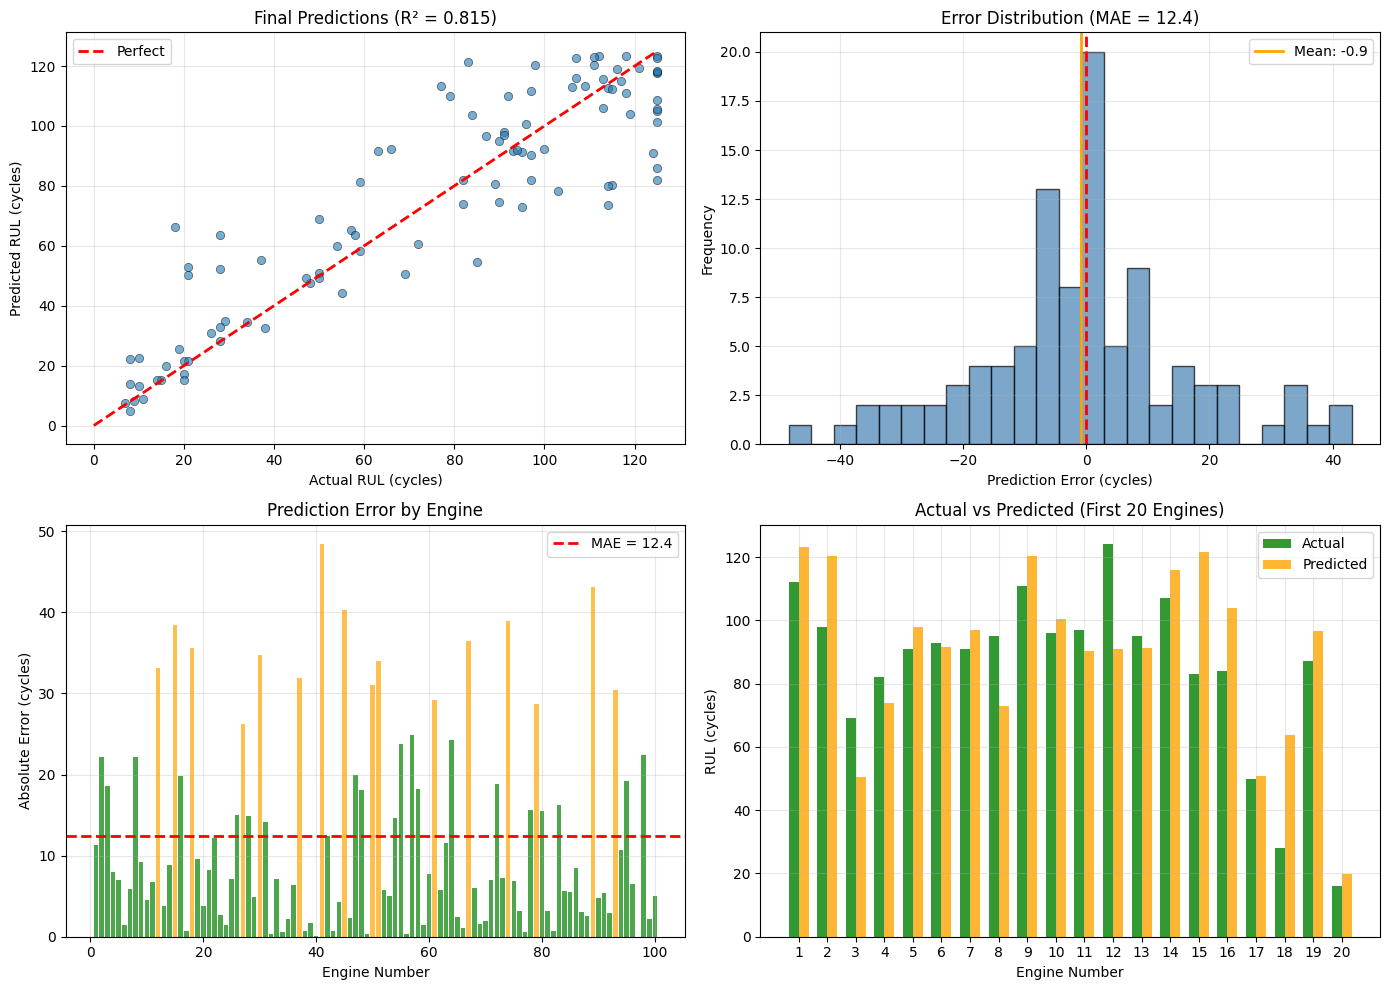


📋 SAMPLE PREDICTIONS (First 10 engines):
----------------------------------------------------------------------
Engine   Actual RUL   Predicted RUL  Error      Status    
----------------------------------------------------------------------
1        112          123.3          -11.3      ✅ Good    
2        98           120.2          -22.2      ⚠️ Fair   
3        69           50.4           +18.6      ✅ Good    
4        82           74.0           +8.0       ✅ Good    
5        91           98.0           -7.0       ✅ Good    
6        93           91.5           +1.5       ✅ Good    
7        91           96.9           -5.9       ✅ Good    
8        95           72.9           +22.1      ⚠️ Fair   
9        111          120.2          -9.2       ✅ Good    
10       96           100.5          -4.5       ✅ Good    
----------------------------------------------------------------------

FINAL VERDICT
✅ EXCELLENT - Model is ready for Docker deployment!
   The model predicts RUL wit

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📊 Test results saved to test_results.csv


In [14]:
# STEP 3: TEST ON UNSEEN FD001 TEST DATA
print("="*70)
print("TESTING MODEL ON FD001 TEST DATA")
print("="*70)

# Prepare test data with RUL
df_test_rul = df_test.copy()
df_test_rul['RUL'] = 0

# For each engine, assign RUL values decreasing from the final RUL
for engine_id in df_test['unit_nr'].unique():
    engine_idx = engine_id - 1
    if engine_idx < len(df_rul):
        final_rul = df_rul.iloc[engine_idx]['RUL']
        engine_cycles = df_test[df_test['unit_nr'] == engine_id]['cycle'].values
        max_cycle = max(engine_cycles)
        for cycle in engine_cycles:
            rul_at_cycle = final_rul + (max_cycle - cycle)
            df_test_rul.loc[(df_test_rul['unit_nr'] == engine_id) &
                              (df_test_rul['cycle'] == cycle), 'RUL'] = max(0, rul_at_cycle)

# Cap RUL
df_test_rul['RUL_capped'] = df_test_rul['RUL'].clip(upper=MAX_RUL)

# Prepare features
X_test = df_test_rul[feature_cols]
y_test = df_test_rul['RUL_capped']

# Scale and predict
X_test_scaled = scaler.transform(X_test)
y_test_pred = model.predict(X_test_scaled)
y_test_pred = np.clip(y_test_pred, 0, MAX_RUL)

# Evaluate on all predictions
test_mae_all = mean_absolute_error(y_test, y_test_pred)
test_rmse_all = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2_all = r2_score(y_test, y_test_pred)

print(f"\n📊 TEST PERFORMANCE (all cycles, {len(y_test):,} predictions):")
print(f"   MAE:  {test_mae_all:.2f} cycles")
print(f"   RMSE: {test_rmse_all:.2f} cycles")
print(f"   R²:   {test_r2_all:.4f}")

# Evaluate only on final predictions (end of life - most important)
final_predictions = []
final_actuals = []

for engine_id in df_test['unit_nr'].unique():
    engine_mask = df_test_rul['unit_nr'] == engine_id
    engine_preds = y_test_pred[engine_mask]
    engine_actuals = y_test[engine_mask]

    # Take last cycle prediction
    final_predictions.append(engine_preds[-1])
    final_actuals.append(engine_actuals.iloc[-1])

final_predictions = np.array(final_predictions)
final_actuals = np.array(final_actuals)

final_mae = mean_absolute_error(final_actuals, final_predictions)
final_rmse = np.sqrt(mean_squared_error(final_actuals, final_predictions))
final_r2 = r2_score(final_actuals, final_predictions)
final_mape = np.mean(np.abs((final_actuals - final_predictions) / (final_actuals + 1))) * 100

print(f"\n📊 FINAL RUL PREDICTION (end of life for {len(final_actuals)} engines):")
print(f"   MAE:  {final_mae:.2f} cycles")
print(f"   RMSE: {final_rmse:.2f} cycles")
print(f"   R²:   {final_r2:.4f}")
print(f"   MAPE: {final_mape:.1f}%")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted (Final)
ax1 = axes[0, 0]
ax1.scatter(final_actuals, final_predictions, alpha=0.6, edgecolors='k', linewidth=0.5)
ax1.plot([0, MAX_RUL], [0, MAX_RUL], 'r--', linewidth=2, label='Perfect')
ax1.set_xlabel('Actual RUL (cycles)')
ax1.set_ylabel('Predicted RUL (cycles)')
ax1.set_title(f'Final Predictions (R² = {final_r2:.3f})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Error Distribution
ax2 = axes[0, 1]
errors = final_actuals - final_predictions
ax2.hist(errors, bins=25, edgecolor='black', alpha=0.7, color='steelblue')
ax2.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax2.axvline(x=np.mean(errors), color='orange', linestyle='-', linewidth=2, label=f'Mean: {np.mean(errors):.1f}')
ax2.set_xlabel('Prediction Error (cycles)')
ax2.set_ylabel('Frequency')
ax2.set_title(f'Error Distribution (MAE = {final_mae:.1f})')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Errors by Engine
ax3 = axes[1, 0]
engine_nums = range(1, len(final_actuals) + 1)
colors = ['green' if e < 25 else 'orange' if e < 50 else 'red' for e in np.abs(errors)]
ax3.bar(engine_nums, np.abs(errors), alpha=0.7, color=colors)
ax3.axhline(y=final_mae, color='r', linestyle='--', linewidth=2, label=f'MAE = {final_mae:.1f}')
ax3.set_xlabel('Engine Number')
ax3.set_ylabel('Absolute Error (cycles)')
ax3.set_title('Prediction Error by Engine')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Comparison for first 20 engines
ax4 = axes[1, 1]
num_show = min(20, len(final_actuals))
x = np.arange(num_show)
width = 0.35
ax4.bar(x - width/2, final_actuals[:num_show], width, label='Actual', alpha=0.8, color='green')
ax4.bar(x + width/2, final_predictions[:num_show], width, label='Predicted', alpha=0.8, color='orange')
ax4.set_xlabel('Engine Number')
ax4.set_ylabel('RUL (cycles)')
ax4.set_title(f'Actual vs Predicted (First {num_show} Engines)')
ax4.set_xticks(x)
ax4.set_xticklabels(range(1, num_show + 1))
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print sample predictions
print("\n📋 SAMPLE PREDICTIONS (First 10 engines):")
print("-" * 70)
print(f"{'Engine':<8} {'Actual RUL':<12} {'Predicted RUL':<14} {'Error':<10} {'Status':<10}")
print("-" * 70)
for i in range(min(10, len(final_actuals))):
    error = final_actuals[i] - final_predictions[i]
    status = "✅ Good" if abs(error) < 20 else "⚠️ Fair" if abs(error) < 40 else "❌ Poor"
    print(f"{i+1:<8} {final_actuals[i]:<12.0f} {final_predictions[i]:<14.1f} {error:<+10.1f} {status:<10}")
print("-" * 70)

# Performance assessment
print("\n" + "="*70)
print("FINAL VERDICT")
print("="*70)

if final_mae < 20:
    print("✅ EXCELLENT - Model is ready for Docker deployment!")
    print("   The model predicts RUL within 20 cycles on average.")
    print("   This is comparable to state-of-the-art results.")
elif final_mae < 30:
    print("👍 GOOD - Model is acceptable for deployment.")
    print("   The model predicts RUL within 30 cycles on average.")
    print("   Will work well for predictive maintenance.")
elif final_mae < 40:
    print("⚠️ FAIR - Model works but has room for improvement.")
    print("   Consider adding more features or tuning hyperparameters.")
else:
    print("❌ POOR - Model needs retraining.")
    print("   Check for data leakage or preprocessing issues.")

print("="*70)

# Save test results
results_df = pd.DataFrame({
    'engine': range(1, len(final_actuals) + 1),
    'actual_rul': final_actuals,
    'predicted_rul': final_predictions,
    'error': errors,
    'abs_error': np.abs(errors)
})
results_df.to_csv('test_results.csv', index=False)
files.download('test_results.csv')

print("\n📊 Test results saved to test_results.csv")